In [6]:
%matplotlib inline

from collections.abc import Callable

import torch
from torch import nn
from d2l import torch as d2l

In [7]:
# 2D Optimization Helper

Gradient2D = Callable[
    [float, float],
    tuple[float, float],
]

Trainer2D = Callable[
    [
        float,
        float,
        float,
        float,
        Gradient2D,
    ],
    tuple[
        float,
        float,
        float,
        float,
    ],
]


def train_2D(
    trainer: Trainer2D,
    gradient: Gradient2D,
    num_steps: int = 20,
) -> list[tuple[float, float]]:
    
    # state1과 state2 이후 Momentum, Adagrad, RMSProp에서 사용
    x1 = -5.0
    x2 = -2.0
    state1 = 0.0
    state2 = 0.0
    
    results = [
        (x1, x2)
    ]
    
    for _ in range(num_steps):
        (
            x1,
            x2,
            state1,
            state2,
        ) = trainer(
            x1,
            x2,
            state1,
            state2,
            gradient,
        )
        
        results.append(
            (x1, x2)
        )
        
        
    print(
        f"step {num_steps}, "
        f"x1: {x1:f}, "
        f"x2: {x2:f}"
    )

    return results

In [8]:
# 2D Optimization Trace

def show_trace_2d(
    objective: Callable[
        [torch.Tensor, torch.Tensor],
        torch.Tensor,
    ],
    results: list[tuple[float, float]],
) -> None:
    points = torch.tensor(
        results
    )

    x1_grid, x2_grid = torch.meshgrid(
        torch.arange(
            -5.5,
            1.0,
            0.1,
        ),
        torch.arange(
            -3.0,
            1.0,
            0.1,
        ),
        indexing="ij",
    )

    d2l.set_figsize()

    d2l.plt.plot(
        points[:, 0],
        points[:, 1],
        "-o",
        color="#ff7f0e",
    )

    d2l.plt.contour(
        x1_grid,
        x2_grid,
        objective(
            x1_grid,
            x2_grid,
        ),
        colors="#1f77b4",
    )

    d2l.plt.xlabel("x1")
    d2l.plt.ylabel("x2")

In [9]:
# Objective Function & Gradient

def objective_2d(
    x1: torch.Tensor,
    x2: torch.Tensor,
) -> torch.Tensor:
    return (
        x1.pow(2) 
        + 2 * x2.pow(2)
    )
    
def objective_gradient_2d(
    x1: float,
    x2: float,
) -> tuple[float, float]:
    return (
        2 * x1,
        4 * x2,
    )

step 20, x1: -0.057646, x2: -0.000073


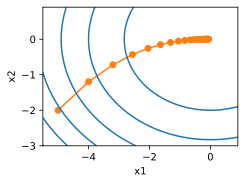

In [10]:
# Multivariate Gradient Descent

learning_rate = 0.1

def gradient_descent_2d(
    x1: float,
    x2: float,
    state1: float,
    state2: float,
    gradient: Gradient2D,
) -> tuple[
    float,
    float,
    float,
    float,
]: 
    del state1, state2

    gradient1, gradient2 = gradient(
        x1,
        x2,
    )
    
    return (
        x1 - learning_rate * gradient1,
        x2 - learning_rate * gradient2,
        0.0,
        0.0,
    )
    
    
results = train_2D(
    trainer=gradient_descent_2d,
    gradient=objective_gradient_2d,
)

show_trace_2d(
    objective_2d,
    results,
)